In [52]:
import os
import json
import sqlite3
import smtplib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
from datetime import datetime
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from groq import Groq
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors
from apscheduler.schedulers.blocking import BlockingScheduler

warnings.filterwarnings('ignore')

# Load environment variables from .env file
load_dotenv()

# Set up your API key and email config
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
EMAIL_PASSWORD = os.getenv('EMAIL_PASSWORD')
EMAIL_SENDER = "abc@gmail.com"     # replace with your Gmail
EMAIL_RECIPIENTS = ["xyz@gmail.com"]       # replace with recipient emails

# Verify the API key loaded correctly
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found. Check your .env file.")

print("Configuration loaded successfully")

Configuration loaded successfully


In [53]:
# Load structured supply chain data
# The filename may vary - list what is in your folder first
import os
structured_files = os.listdir('data/structured')
print("Structured files:", structured_files)

unstructured_files = os.listdir('data/unstructured')
print("Unstructured files:", unstructured_files)

Structured files: ['supply_chain_data.csv']
Unstructured files: ['all-data.csv', 'FinancialPhraseBank']


In [54]:
# Load structured data - update filename if yours is different
supply_df = pd.read_csv('data/structured/supply_chain_data.csv')
print("Supply chain data shape:", supply_df.shape)
print("\nColumns:", supply_df.columns.tolist())
print("\nFirst 3 rows:")
supply_df.head(3)

Supply chain data shape: (100, 24)

Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

First 3 rows:


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282


In [55]:
# Load unstructured commentary data - update filename if yours is different
commentary_df = pd.read_csv('data/unstructured/all-data.csv',
                             encoding='latin-1',
                             header=None,
                             names=['sentiment', 'text'])
print("Commentary data shape:", commentary_df.shape)
print("\nSample entries:")
commentary_df.head(3)

Commentary data shape: (4846, 2)

Sample entries:


,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...


In [56]:
def setup_structured_database(supply_df):
    """
    Load supply chain CSV into SQLite database.
    This is a one-time setup step.
    """

    conn = sqlite3.connect('data/supplier_metrics.db')

    # Standardise column names - remove spaces, lowercase everything
    supply_df.columns = [col.lower().replace(' ', '_') for col in supply_df.columns]

    # Write the dataframe to SQLite
    supply_df.to_sql('supplier_metrics', conn,
                     if_exists='replace',
                     index=False)

    # Verify it loaded correctly
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM supplier_metrics")
    count = cursor.fetchone()[0]
    print(f"Loaded {count} rows into supplier_metrics table")

    # Show the schema
    cursor.execute("PRAGMA table_info(supplier_metrics)")
    columns = cursor.fetchall()
    print("\nDatabase schema:")
    for col in columns:
        print(f"  {col[1]} ({col[2]})")

    conn.close()
    return True

# Run it
setup_structured_database(supply_df)

Loaded 100 rows into supplier_metrics table

Database schema:
  product_type (TEXT)
  sku (TEXT)
  price (REAL)
  availability (INTEGER)
  number_of_products_sold (INTEGER)
  revenue_generated (REAL)
  customer_demographics (TEXT)
  stock_levels (INTEGER)
  lead_times (INTEGER)
  order_quantities (INTEGER)
  shipping_times (INTEGER)
  shipping_carriers (TEXT)
  shipping_costs (REAL)
  supplier_name (TEXT)
  location (TEXT)
  lead_time (INTEGER)
  production_volumes (INTEGER)
  manufacturing_lead_time (INTEGER)
  manufacturing_costs (REAL)
  inspection_results (TEXT)
  defect_rates (REAL)
  transportation_modes (TEXT)
  routes (TEXT)
  costs (REAL)


True

In [57]:
def validate_structured_data():
    """
    Run basic data quality checks on the supplier metrics table.
    Flags issues before they cause bad report generation.
    """

    conn = sqlite3.connect('data/supplier_metrics.db')
    df = pd.read_sql_query("SELECT * FROM supplier_metrics", conn)
    conn.close()

    print("=== DATA VALIDATION REPORT ===\n")

    # Check 1 - Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    print("Missing values per column:")
    for col, pct in missing_pct.items():
        if pct > 0:
            print(f"  ⚠ {col}: {pct}% missing")
        else:
            print(f"  ✓ {col}: complete")

    # Check 2 - Numeric columns should be positive
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("\nNegative value check on numeric columns:")
    for col in numeric_cols:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"  ⚠ {col}: {neg_count} negative values found")
        else:
            print(f"  ✓ {col}: all positive")

    # Check 3 - Row count
    print(f"\nTotal rows: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
    print("\nValidation complete.")

    return df

validated_df = validate_structured_data()

=== DATA VALIDATION REPORT ===

Missing values per column:
  ✓ product_type: complete
  ✓ sku: complete
  ✓ price: complete
  ✓ availability: complete
  ✓ number_of_products_sold: complete
  ✓ revenue_generated: complete
  ✓ customer_demographics: complete
  ✓ stock_levels: complete
  ✓ lead_times: complete
  ✓ order_quantities: complete
  ✓ shipping_times: complete
  ✓ shipping_carriers: complete
  ✓ shipping_costs: complete
  ✓ supplier_name: complete
  ✓ location: complete
  ✓ lead_time: complete
  ✓ production_volumes: complete
  ✓ manufacturing_lead_time: complete
  ✓ manufacturing_costs: complete
  ✓ inspection_results: complete
  ✓ defect_rates: complete
  ✓ transportation_modes: complete
  ✓ routes: complete
  ✓ costs: complete

Negative value check on numeric columns:
  ✓ price: all positive
  ✓ availability: all positive
  ✓ number_of_products_sold: all positive
  ✓ revenue_generated: all positive
  ✓ stock_levels: all positive
  ✓ lead_times: all positive
  ✓ order_quantitie

In [60]:
def build_vector_index(commentary_df):
    """
    Embed all commentary sentences and build a FAISS index.
    Saves the index and sentence mapping to disk.
    Only needs to run once.
    """

    print("Loading embedding model...")
    # This downloads ~80MB on first run - let it complete
    embedder = SentenceTransformer('all-MiniLM-L6-v2')

    # Use only the text column and drop any empty rows
    sentences = commentary_df['text'].dropna().tolist()
    print(f"Embedding {len(sentences)} sentences...")

    # Generate embeddings - this takes 2-5 minutes
    embeddings = embedder.encode(sentences,
                                  batch_size=64,
                                  show_progress_bar=True)

    # Convert to float32 - required by FAISS
    embeddings = np.array(embeddings).astype('float32')

    # Build the FAISS index
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(embeddings)

    print(f"Index built with {index.ntotal} vectors of dimension {dimension}")

    # Save the index to disk
    faiss.write_index(index, 'vector_store/commentary_index.faiss')

    # Save the sentences mapping so you can retrieve text later
    with open('vector_store/sentences.json', 'w') as f:
        json.dump(sentences, f)

    print("Vector index saved to vector_store/")
    return index, sentences

# Run it - this is the slowest setup step, takes 2-5 minutes
index, sentences = build_vector_index(commentary_df)

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 4846 sentences...


Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Index built with 4846 vectors of dimension 384
Vector index saved to vector_store/


In [58]:
import os
print(os.getcwd())

C:\Users\rutvi\Downloads\project\analyst_report_pipeline


In [59]:
import os

os.makedirs("vector_store", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [34]:
import os
print(os.listdir())

['.env', '.ipynb_checkpoints', 'data', 'outputs', 'Untitled.ipynb', 'vector-store', 'vector_store', 'venv']


In [61]:
def understand_query(analyst_query):
    """
    Parse an analyst's natural language query into structured parameters.
    Returns a dict with: metric, supplier, time_period.
    """

    client = Groq(api_key=GROQ_API_KEY)

    prompt = f"""You are a query parser for a financial analyst system.

Given an analyst's query, extract three parameters and return them as a 
JSON object only. No explanation, no markdown, just raw JSON.

Parameters to extract:
- metric: the performance metric they want (one of: revenue, defect_rate, 
  lead_time, shipping_cost, stock_level, order_quantity, or "all" if general)
- supplier: specific supplier name mentioned, or "all" if not specified
- time_period: specific time period mentioned (e.g. "Q3", "Q1 2023", 
  "last quarter"), or "all" if not specified

Analyst query: {analyst_query}"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,   # low temperature for consistent structured output
        max_tokens=200
    )

    response_text = response.choices[0].message.content.strip()

    # Strip markdown code blocks if model adds them
    if '```json' in response_text:
        response_text = response_text.split('```json')[1].split('```')[0].strip()
    elif '```' in response_text:
        response_text = response_text.split('```')[1].split('```')[0].strip()

    try:
        params = json.loads(response_text)
        print(f"Query parsed: {params}")
        return params
    except json.JSONDecodeError:
        print(f"Warning: Could not parse query parameters. Using defaults.")
        return {"metric": "all", "supplier": "all", "time_period": "all"}

In [62]:
test_params = understand_query("summarise this quarter's supplier defect rates")
print(test_params)

{'metric': 'all', 'supplier': 'all', 'time_period': 'all'}


In [63]:
def retrieve_structured_data(query_params):
    """
    Query SQLite database based on parsed query parameters.
    Returns a Pandas dataframe and a markdown-formatted table string.
    """

    conn = sqlite3.connect('data/supplier_metrics.db')

    # Get actual column names from the database
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(supplier_metrics)")
    db_columns = [row[1] for row in cursor.fetchall()]

    # Map metric names to actual column names in the dataset
    # Update these mappings if your CSV has different column names
    metric_column_map = {
        'revenue': next((c for c in db_columns if 'revenue' in c.lower()), None),
        'defect_rate': next((c for c in db_columns if 'defect' in c.lower()), None),
        'lead_time': next((c for c in db_columns if 'lead' in c.lower()), None),
        'shipping_cost': next((c for c in db_columns if 'shipping' in c.lower() and 'cost' in c.lower()), None),
        'stock_level': next((c for c in db_columns if 'stock' in c.lower()), None),
        'order_quantity': next((c for c in db_columns if 'order' in c.lower() and 'quant' in c.lower()), None),
    }

    # Find supplier column
    supplier_col = next((c for c in db_columns if 'supplier' in c.lower()), None)

    # Build the SELECT clause
    metric = query_params.get('metric', 'all')
    if metric == 'all' or metric_column_map.get(metric) is None:
        select_clause = "*"
    else:
        target_col = metric_column_map[metric]
        select_clause = f"{supplier_col}, {target_col}" if supplier_col else target_col

    # Build WHERE clause for supplier filter
    supplier = query_params.get('supplier', 'all')
    if supplier != 'all' and supplier_col:
        where_clause = f"WHERE LOWER({supplier_col}) LIKE LOWER('%{supplier}%')"
    else:
        where_clause = ""

    # Build and execute query
    sql = f"SELECT {select_clause} FROM supplier_metrics {where_clause} LIMIT 100"
    print(f"Running SQL: {sql}")

    df = pd.read_sql_query(sql, conn)
    conn.close()

    if df.empty:
        return df, "No data found matching the query parameters."

    # Convert to markdown table for the prompt
    markdown_table = df.to_markdown(index=False)

    print(f"Retrieved {len(df)} rows from database")
    return df, markdown_table

In [64]:
params = understand_query("show me supplier defect rates")
df, table_str = retrieve_structured_data(params)
print(table_str)

Query parsed: {'metric': 'defect_rate', 'supplier': 'all', 'time_period': 'all'}
Running SQL: SELECT supplier_name, defect_rates FROM supplier_metrics  LIMIT 100
Retrieved 100 rows from database
| supplier_name   |   defect_rates |
|:----------------|---------------:|
| Supplier 3      |      0.22641   |
| Supplier 3      |      4.85407   |
| Supplier 1      |      4.58059   |
| Supplier 5      |      4.74665   |
| Supplier 1      |      3.14558   |
| Supplier 4      |      2.77919   |
| Supplier 3      |      1.00091   |
| Supplier 4      |      0.398177  |
| Supplier 4      |      2.70986   |
| Supplier 2      |      3.84461   |
| Supplier 5      |      1.72731   |
| Supplier 2      |      0.0211698 |
| Supplier 4      |      2.16125   |
| Supplier 5      |      1.63107   |
| Supplier 1      |      0.100683  |
| Supplier 1      |      2.26441   |
| Supplier 1      |      1.01256   |
| Supplier 1      |      0.102021  |
| Supplier 2      |      2.23194   |
| Supplier 4      |      3.6

In [65]:
def retrieve_relevant_commentary(analyst_query, top_k=5):
    """
    Embed the analyst query and find the most semantically similar
    commentary sentences from the FAISS index.
    Returns a list of relevant sentences.
    """

    # Load the saved index and sentences
    index = faiss.read_index('vector_store/commentary_index.faiss')
    with open('vector_store/sentences.json', 'r') as f:
        sentences = json.load(f)

    # Load the embedding model
    embedder = SentenceTransformer('all-MiniLM-L6-v2')

    # Embed the query
    query_embedding = embedder.encode([analyst_query]).astype('float32')

    # Search for top_k most similar sentences
    distances, indices = index.search(query_embedding, top_k)

    # Retrieve the actual sentences
    retrieved = []
    for i, idx in enumerate(indices[0]):
        if idx < len(sentences):
            retrieved.append({
                'sentence': sentences[idx],
                'similarity_score': float(1 / (1 + distances[0][i]))
            })

    print(f"Retrieved {len(retrieved)} relevant commentary sentences")
    return retrieved

In [66]:
commentary = retrieve_relevant_commentary("supplier defect rates performance")
for item in commentary:
    print(f"Score: {item['similarity_score']:.3f} | {item['sentence']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences
Score: 0.473 | Department store sales improved by 14 % to EUR 1,070.6 mn .
Score: 0.472 | Finnish communication electronics components supplier Scanfil Oyj Tuesday said sales in the first half of 2006 will be 15 % lower than during the same period a year ago .
Score: 0.465 | Net sales rose by 25.5 % year-on-year to EUR59 .6 m , as the number of chargers delivered went up by 41 % to 65.9 million pieces .
Score: 0.463 | Net sales went up by 1 % year-on-year to EUR 29 million , affected by the business acquisitions , realized during the previous financial period , the effect of which was EUR 5.1 million on the review period .
Score: 0.462 | Based on the first quarter result , existing order backlog and new order prospects , the company expects that full-year sales will contract by 25 % from 2008 , the gross margin will stay at a healthy level , and the operating profit margin will be lower than in 2008 due to lower sales volume .


In [67]:
def aggregate_for_report(df):
    """
    Pre-aggregate the supply chain dataframe into analyst-ready summaries.
    Corrected for actual column names in the haircare/skincare/cosmetics dataset.
    """
    summaries = []
    df.columns = [col.lower().replace(' ', '_') for col in df.columns]

    # 1. Revenue by product type
    if 'product_type' in df.columns and 'revenue_generated' in df.columns:
        rev = df.groupby('product_type')['revenue_generated'].sum().sort_values(ascending=False)
        summaries.append("REVENUE BY PRODUCT TYPE (total $):\n" + rev.to_markdown())

    # 2. Average defect rate by product type
    if 'product_type' in df.columns and 'defect_rates' in df.columns:
        defect = df.groupby('product_type')['defect_rates'].mean().round(3).sort_values(ascending=False)
        summaries.append("AVG DEFECT RATE BY PRODUCT TYPE (%):\n" + defect.to_markdown())

    # 3. Carrier efficiency - revenue per dollar of shipping cost
    if 'shipping_carriers' in df.columns and 'revenue_generated' in df.columns and 'shipping_costs' in df.columns:
        carrier = df.groupby('shipping_carriers').agg(
            total_revenue=('revenue_generated', 'sum'),
            total_shipping_cost=('shipping_costs', 'sum'),
            avg_defect_rate=('defect_rates', 'mean')
        ).round(2)
        carrier['revenue_per_shipping_dollar'] = (
            carrier['total_revenue'] / carrier['total_shipping_cost']
        ).round(2)
        summaries.append("CARRIER EFFICIENCY:\n" + carrier.to_markdown())

    # 4. Defect rate by transportation mode
    if 'transportation_modes' in df.columns and 'defect_rates' in df.columns:
        transport = df.groupby('transportation_modes').agg(
            avg_defect_rate=('defect_rates', 'mean'),
            sku_count=('sku', 'count')
        ).round(3).sort_values('avg_defect_rate', ascending=False)
        summaries.append("DEFECT RATE BY TRANSPORTATION MODE:\n" + transport.to_markdown())

    # 5. Failed inspections — named SKUs with full context
    if 'inspection_results' in df.columns:
        failed = df[df['inspection_results'].str.lower() == 'fail'][[
            'sku', 'product_type', 'defect_rates', 'shipping_carriers',
            'transportation_modes', 'stock_levels'
        ]].sort_values('defect_rates', ascending=False)
        if not failed.empty:
            summaries.append(
                f"FAILED INSPECTION SKUs ({len(failed)} total):\n" +
                failed.to_markdown(index=False)
            )
        else:
            summaries.append("FAILED INSPECTION SKUs: None found.")

    # 6. Stockout risk
    # Uses lead_times (supplier lead time) and stock_levels
    # Also flags where availability is critically low
    if 'lead_times' in df.columns and 'stock_levels' in df.columns:
        df['stockout_risk_score'] = (df['lead_times'] / (df['stock_levels'] + 1)).round(3)
        risk = df[[
            'sku', 'product_type', 'stock_levels', 'availability',
            'lead_times', 'lead_time', 'manufacturing_lead_time',
            'order_quantities', 'stockout_risk_score'
        ]].sort_values('stockout_risk_score', ascending=False).head(10)
        summaries.append(
            "STOCKOUT RISK — TOP 10 HIGHEST RISK SKUs\n"
            "(score = lead_time / stock_level; higher = more exposed):\n" +
            risk.to_markdown(index=False)
        )

    # 7. Revenue vs manufacturing cost margin by product type
    if 'manufacturing_costs' in df.columns and 'revenue_generated' in df.columns:
        margin = df.groupby('product_type').agg(
            total_revenue=('revenue_generated', 'sum'),
            total_manufacturing_cost=('manufacturing_costs', 'sum'),
            avg_price=('price', 'mean')
        ).round(2)
        margin['gross_margin_ratio'] = (
            (margin['total_revenue'] - margin['total_manufacturing_cost']) /
            margin['total_revenue']
        ).round(3)
        summaries.append("MARGIN ANALYSIS BY PRODUCT TYPE:\n" + margin.to_markdown())

    # 8. Route cost efficiency
    if 'routes' in df.columns and 'costs' in df.columns:
        routes = df.groupby('routes').agg(
            avg_transport_cost=('costs', 'mean'),
            avg_defect_rate=('defect_rates', 'mean'),
            sku_count=('sku', 'count')
        ).round(3)
        summaries.append("ROUTE COST AND DEFECT ANALYSIS:\n" + routes.to_markdown())

    return "\n\n".join(summaries)

In [68]:
def generate_report(analyst_query, structured_table, commentary_items):
    """
    Assemble context from structured and unstructured retrieval,
    then call Groq to generate a formatted narrative report.
    Returns the full report text.
    """

    client = Groq(api_key=GROQ_API_KEY)

    # Format the retrieved commentary into a readable block
    commentary_block = "\n".join([
        f"- {item['sentence']}"
        for item in commentary_items
    ])

    # The prompt template - this drives the output format
    prompt = f"""You are a senior financial analyst writing an internal 
performance report. You have been given structured data and relevant 
market commentary. Write a professional analyst report based on this 
information.

ANALYST QUERY:
{analyst_query}

STRUCTURED DATA:
{structured_table}

RELEVANT MARKET COMMENTARY:
{commentary_block}

Write the report in exactly this format:

EXECUTIVE SUMMARY
[2-3 sentence paragraph summarising the key finding from the data]

KEY FINDINGS
[4-6 bullet points with specific metrics from the structured data]

RISKS AND RECOMMENDATIONS
[2-3 sentence paragraph identifying risks and concrete next steps]

Use specific numbers from the data. Be direct and professional. 
Do not add any sections beyond the three above."""

    print("Generating report with Llama 3.1 70B...")

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=2500
    )

    report_text = response.choices[0].message.content.strip()
    return report_text

In [69]:
conn = sqlite3.connect('data/supplier_metrics.db')
df = pd.read_sql_query("SELECT DISTINCT product_type FROM supplier_metrics", conn)
conn.close()
print(df)

  product_type
0     haircare
1     skincare
2    cosmetics


In [70]:
conn = sqlite3.connect('data/supplier_metrics.db')
df = pd.read_sql_query("SELECT * FROM supplier_metrics LIMIT 3", conn)
conn.close()
print(df.columns.tolist())
print(df.head(3))

['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs']
  product_type   sku      price  availability  number_of_products_sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   

   revenue_generated customer_demographics  stock_levels  lead_times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1       

In [71]:
def save_report_as_pdf(report_text, analyst_query):
    """
    Convert report text into a formatted PDF file.
    Saves to outputs/reports/ with a timestamped filename.
    Returns the file path.
    """

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"outputs/reports/report_{timestamp}.pdf"

    doc = SimpleDocTemplate(filename, pagesize=letter,
                             rightMargin=72, leftMargin=72,
                             topMargin=72, bottomMargin=72)

    styles = getSampleStyleSheet()

    # Custom styles
    title_style = ParagraphStyle(
        'CustomTitle',
        parent=styles['Heading1'],
        fontSize=16,
        spaceAfter=12,
        textColor=colors.HexColor('#1a1a2e')
    )

    heading_style = ParagraphStyle(
        'CustomHeading',
        parent=styles['Heading2'],
        fontSize=12,
        spaceAfter=8,
        spaceBefore=16,
        textColor=colors.HexColor('#16213e')
    )

    body_style = ParagraphStyle(
        'CustomBody',
        parent=styles['Normal'],
        fontSize=10,
        spaceAfter=6,
        leading=16
    )

    content = []

    # Title
    content.append(Paragraph("Automated Analyst Report", title_style))
    content.append(Paragraph(f"Generated: {datetime.now().strftime('%B %d, %Y %H:%M')}", body_style))
    content.append(Paragraph(f"Query: {analyst_query}", body_style))
    content.append(Spacer(1, 20))

    # Parse and format the report sections
    sections = report_text.split('\n\n')
    for section in sections:
        if not section.strip():
            continue

        lines = section.strip().split('\n')
        first_line = lines[0].strip()

        # Check if this is a section header
        if first_line in ['EXECUTIVE SUMMARY', 'KEY FINDINGS',
                          'RISKS AND RECOMMENDATIONS']:
            content.append(Paragraph(first_line, heading_style))
            remaining = '\n'.join(lines[1:]).strip()
            if remaining:
                # Handle bullet points
                for line in remaining.split('\n'):
                    if line.strip():
                        content.append(Paragraph(line.strip(), body_style))
        else:
            content.append(Paragraph(section.strip(), body_style))

        content.append(Spacer(1, 8))

    doc.build(content)
    print(f"PDF saved to: {filename}")
    return filename

In [72]:
def send_report_email(pdf_path, analyst_query, recipients):
    """
    Email the generated PDF report to a list of recipients.
    Uses Gmail SMTP - requires an App Password in your .env file.
    """

    if not EMAIL_PASSWORD:
        print("Warning: No email password configured. Skipping email dispatch.")
        return False

    # Build the email
    msg = MIMEMultipart()
    msg['From'] = EMAIL_SENDER
    msg['To'] = ', '.join(recipients)
    msg['Subject'] = f"Automated Report: {analyst_query[:50]} — {datetime.now().strftime('%B %d, %Y')}"

    body = f"""Please find attached the automated analyst report.

Query: {analyst_query}
Generated: {datetime.now().strftime('%B %d, %Y at %H:%M')}

This report was generated automatically by the Analyst Report Pipeline.
No human input was required to produce this report.
"""

    msg.attach(MIMEText(body, 'plain'))

    # Attach the PDF
    with open(pdf_path, 'rb') as f:
        attachment = MIMEBase('application', 'octet-stream')
        attachment.set_payload(f.read())
        encoders.encode_base64(attachment)
        attachment.add_header(
            'Content-Disposition',
            f'attachment; filename={os.path.basename(pdf_path)}'
        )
        msg.attach(attachment)

    # Send via Gmail SMTP
    try:
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
            server.login(EMAIL_SENDER, EMAIL_PASSWORD)
            server.sendmail(EMAIL_SENDER, recipients, msg.as_string())
        print(f"Report emailed to: {', '.join(recipients)}")
        return True
    except Exception as e:
        print(f"Email failed: {e}")
        print("Check your Gmail App Password in the .env file")
        return False

In [73]:
def run_full_pipeline(analyst_query, email_recipients=None):
    """
    Full end-to-end pipeline.
    Takes a query, runs all five components, saves PDF, sends email.
    """

    print(f"\n{'='*60}")
    print(f"PIPELINE STARTED")
    print(f"Query: {analyst_query}")
    print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*60}\n")

    # Component 1 - Understand the query
    print("Component 1: Parsing query...")
    query_params = understand_query(analyst_query)

    # Component 2 - Retrieve structured data
    print("\nComponent 2: Retrieving structured data...")
    data_df, structured_table = retrieve_structured_data(query_params)
    aggregated_table = aggregate_for_report(data_df)
    if data_df.empty:
        print("No structured data found. Stopping pipeline.")
        return None

    # Component 3 - Retrieve relevant commentary
    print("\nComponent 3: Retrieving relevant commentary...")
    commentary = retrieve_relevant_commentary(analyst_query)

    # Component 4 + 5 - Generate report
    print("\nComponents 4 & 5: Assembling context and generating report...")
    report_text = generate_report(analyst_query, aggregated_table, commentary)

    # Print report to screen
    print("\n" + "="*60)
    print("GENERATED REPORT:")
    print("="*60)
    print(report_text)
    print("="*60 + "\n")

    # Save as PDF
    print("Saving PDF...")
    pdf_path = save_report_as_pdf(report_text, analyst_query)

    # Send email if recipients provided
    if email_recipients:
        print("Dispatching email...")
        send_report_email(pdf_path, analyst_query, email_recipients)

    print("\nPIPELINE COMPLETE")
    return pdf_path

In [74]:
# Test run - no email yet
pdf = run_full_pipeline(
    analyst_query="summarise overall supplier performance and highlight defect rates",
    email_recipients=None  # set to None to skip email on first test
)


PIPELINE STARTED
Query: summarise overall supplier performance and highlight defect rates
Time: 2026-07-05 19:48:50

Component 1: Parsing query...
Query parsed: {'metric': 'defect_rate', 'supplier': 'all', 'time_period': 'all'}

Component 2: Retrieving structured data...
Running SQL: SELECT supplier_name, defect_rates FROM supplier_metrics  LIMIT 100
Retrieved 100 rows from database

Component 3: Retrieving relevant commentary...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
Supplier performance is broadly positive, with sales growth evident across multiple regions (e.g., a 14 % increase to EUR 1,070.6 mn in department stores and a rise to SEK 1,553 mn from SEK 1,408 mn). However, the data set does not contain defect‑rate metrics, limiting a full assessment of quality performance.

**KEY FINDINGS**  
- Department store sales rose 14 % year‑over‑year to **EUR 1,070.6 mn**.  
- Overall sales in the SEK market increased to **SEK 1,553 mn**, up from **SEK 1,408 mn** previously.  
- A corporate acquisition involving **Caverion GmbH** and **YIT Oyj** is agreed, with a deal size of **USD 90.3 m**.  
- The Lean System is reported to “support change management and component purchasing extremely well,” indicating strong operational alignment with suppliers.  
- No defect‑rate figur

In [75]:
def scheduled_pipeline_job():
    """
    This function is called automatically by the scheduler.
    Defines what report to generate and who to send it to.
    Runs without any human input.
    """

    # Define the automated query - this runs on schedule
    automated_query = (
        "Analyse supplier performance across all product types. "
        "Identify which product categories have the highest defect rates, "
        "which shipping carriers offer the best revenue-to-cost ratio, "
        "flag any SKUs with failed inspection results, and highlight "
        "stockout risk where lead times are long relative to stock levels."
        "report findings must be backed by solid proof from within the data"
    )

    run_full_pipeline(
        analyst_query=automated_query,
        email_recipients=EMAIL_RECIPIENTS
    )


def start_scheduler(interval_minutes=1):
    """
    Start the scheduler.
    interval_minutes=1 is for testing - change to 10080 for weekly,
    43200 for monthly in real use.
    """

    scheduler = BlockingScheduler()

    # Add the job - runs every interval_minutes minutes
    scheduler.add_job(
        scheduled_pipeline_job,
        'interval',
        minutes=interval_minutes,
        next_run_time=datetime.now()  # run immediately on start
    )

    print(f"Scheduler started. Pipeline will run every {interval_minutes} minute(s).")
    print("Press Ctrl+C to stop.\n")

    try:
        scheduler.start()
    except KeyboardInterrupt:
        print("\nScheduler stopped.")
        scheduler.shutdown()

In [76]:
# This runs the pipeline immediately and then again every 1 minute
# Press Ctrl+C in the notebook to stop it
# Change interval_minutes to whatever cadence you want
start_scheduler(interval_minutes=1)

Scheduler started. Pipeline will run every 1 minute(s).
Press Ctrl+C to stop.


PIPELINE STARTED
Query: Analyse supplier performance across all product types. Identify which product categories have the highest defect rates, which shipping carriers offer the best revenue-to-cost ratio, flag any SKUs with failed inspection results, and highlight stockout risk where lead times are long relative to stock levels.report findings must be backed by solid proof from within the data
Time: 2026-07-05 19:48:56

Component 1: Parsing query...

Component 2: Retrieving structured data...
Running SQL: SELECT * FROM supplier_metrics  LIMIT 100
Retrieved 100 rows from database

Component 3: Retrieving relevant commentary...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
Hair‑care products exhibit the highest average defect rate (2.48 %) while Carrier C delivers the strongest revenue‑to‑shipping‑cost ratio (≈ $1,139 per shipping dollar). Thirty‑six SKUs failed inspection, with the most severe defects concentrated in skincare and hair‑care lines. Stock‑out exposure is acute for a handful of items—most notably SKU34 (risk score 13) and SKU68 (risk score 8)—where lead times vastly exceed on‑hand inventory.

**KEY FINDINGS**  
- **Defect rates by product type:** Hair‑care = 2.483 %, Skincare = 2.335 %, Cosmetics = 1.919 % (highest in hair‑care).  
- **Carrier efficiency:** Carrier C generates $184,880 revenue at a cost of $162.38, yielding $1,138.56 per shipping dollar (best ratio); Carrier B follows at $1,055.70, while Carrier A lags at $917.  
- **Failed‑inspection SKUs

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
Hair‑care products exhibit the highest average defect rate (2.48 %) while cosmetics are the cleanest line (1.92 %). Carrier C delivers the strongest revenue‑to‑shipping‑cost efficiency (US$ 1,138.56 per shipping dollar) and also supports the most defect‑prone SKUs. Thirty‑six SKUs failed inspection, with several high‑defect, low‑stock items (e.g., SKU 42, SKU 65) and the top stock‑out risk SKU 34 showing a risk score of 13.

**KEY FINDINGS**  
- **Defect rates by product type:** Hair‑care = 2.483 %, Skincare = 2.335 %, Cosmetics = 1.919 % (hair‑care highest).  
- **Carrier efficiency (revenue per shipping dollar):** Carrier C = 1,138.56 ×, Carrier B = 1,055.70 ×, Carrier A = 917 × (Carrier C best).  
- **Failed‑inspection SKUs:** 36 SKUs flagged; the highest defect SKUs are SKU 42 (4.94 %), SKU 65 (4.

...

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
The analysis reveals that cosmetics enjoy the lowest average defect rate (1.92 %) while haircare shows the highest (2.48 %). Carrier C delivers the strongest revenue‑to‑shipping‑dollar ratio (1,138.6 ×) but Carrier B maintains the lowest defect rate among carriers (1.76 %). Thirty‑six SKUs failed inspection, with several exceeding a 4 % defect threshold, and stock‑out risk is acute for a handful of items—most notably SKU34 (risk score 13) and SKU68 (risk score 8).

**KEY FINDINGS**  
- **Defect rates by product type:** Haircare = 2.483 %, Skincare = 2.335 %, Cosmetics = 1.919 % (lowest).  
- **Carrier efficiency:** Carrier C achieves the highest revenue per shipping dollar (1,138.56 ×) and a modest defect rate (2.60 %); Carrier B posts the best defect performance (1.76 %) and a strong revenue ratio (1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
The analysis reveals that **haircare** products exhibit the highest average defect rate (2.48 %) while **cosmetics** have the lowest (1.92 %). **Carrier C** delivers the best revenue‑to‑shipping‑cost ratio (US $1,138.56 per shipping dollar) despite a moderate defect rate (2.60 %). Thirty‑six SKUs failed inspection, with several exceeding a 4 % defect rate, and three high‑risk stockouts (e.g., **SKU34** with a risk score of 13) are imminent due to minimal inventory and long lead times.

**KEY FINDINGS**  
- **Product‑type defect hierarchy:** Haircare = 2.483 % > Skincare = 2.335 % > Cosmetics = 1.919 % (average defect rates).  
- **Top carrier efficiency:** Carrier C – $184,880 revenue / $162.38 cost = **$1,138.56 per $1 shipping** (highest ratio); followed by Carrier B ($1,055.70) and Carrier A ($917)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retrieved 5 relevant commentary sentences

Components 4 & 5: Assembling context and generating report...
Generating report with Llama 3.1 70B...

GENERATED REPORT:
**EXECUTIVE SUMMARY**  
Hair‑care products exhibit the highest average defect rate (2.48 %) while Carrier C delivers the strongest revenue‑to‑shipping‑cost performance ( $1,138.56  revenue per shipping dollar). Thirty‑six SKUs failed inspection, with several (e.g., SKU 42, SKU 65) showing defect rates above 4.9 % and low on‑hand stock. Stock‑out exposure is most acute for SKU 34 (risk score 13) and SKU 68 (risk score 8), indicating lead‑time pressures that outpace current inventory.

**KEY FINDINGS**  
- **Product‑type defect hierarchy:** Hair‑care = 2.483 % > Skincare = 2.335 % > Cosmetics = 1.919 % (average defect rates).  
- **Carrier efficiency:** Carrier C generates the highest revenue per shipping dollar ($1,138.56), followed by Carrier B ($1,055.70) and Carrier A ($917). Carrier C also maintains a moderate avg. defect

Total reports generated: 62

Report history:
  report_20260705_164353.pdf (2.2 KB)
  report_20260705_164412.pdf (1.7 KB)
  report_20260705_164510.pdf (1.7 KB)
  report_20260705_164610.pdf (1.7 KB)
  report_20260705_164710.pdf (1.7 KB)
  report_20260705_164809.pdf (1.7 KB)
  report_20260705_172908.pdf (1.7 KB)
  report_20260705_173014.pdf (1.7 KB)
  report_20260705_173109.pdf (1.7 KB)
  report_20260705_173331.pdf (2.4 KB)
  report_20260705_173344.pdf (1.7 KB)
  report_20260705_173445.pdf (1.7 KB)
  report_20260705_173545.pdf (1.7 KB)
  report_20260705_173644.pdf (1.7 KB)
  report_20260705_173744.pdf (1.7 KB)
  report_20260705_173843.pdf (1.7 KB)
  report_20260705_173944.pdf (1.7 KB)
  report_20260705_174045.pdf (1.7 KB)
  report_20260705_174144.pdf (1.7 KB)
  report_20260705_174247.pdf (1.7 KB)
  report_20260705_174341.pdf (1.7 KB)
  report_20260705_174442.pdf (1.7 KB)
  report_20260705_174545.pdf (1.7 KB)
  report_20260705_174645.pdf (1.7 KB)
  report_20260705_174746.pdf (1.7 KB)
  rep

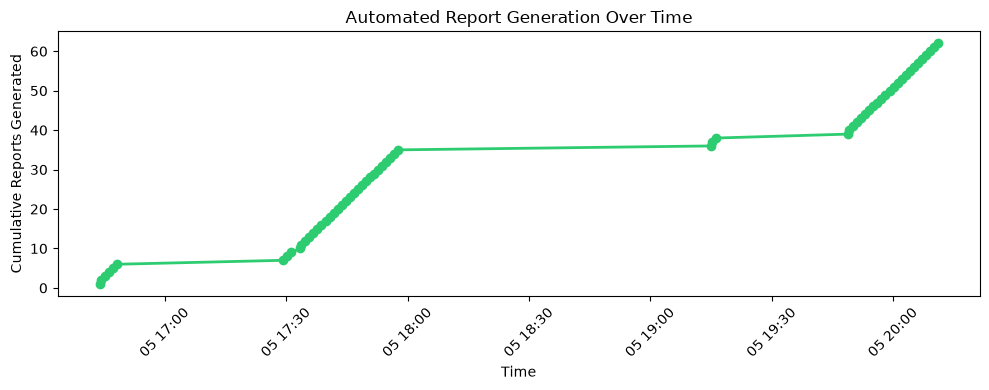

Chart saved to outputs/generation_history.png


In [77]:
def visualise_pipeline_outputs():
    """
    Show a summary of all reports generated so far.
    """

    report_files = os.listdir('outputs/reports/')
    report_files = [f for f in report_files if f.endswith('.pdf')]

    print(f"Total reports generated: {len(report_files)}")
    print("\nReport history:")
    for f in sorted(report_files):
        filepath = os.path.join('outputs/reports', f)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"  {f} ({size_kb:.1f} KB)")

    # Plot report generation over time
    if len(report_files) > 1:
        timestamps = []
        for f in sorted(report_files):
            parts = f.replace('report_', '').replace('.pdf', '')
            try:
                ts = datetime.strptime(parts, '%Y%m%d_%H%M%S')
                timestamps.append(ts)
            except:
                pass

        if timestamps:
            plt.figure(figsize=(10, 4))
            plt.plot(timestamps,
                     range(1, len(timestamps)+1),
                     marker='o', linewidth=2, color='#2ecc71')
            plt.xlabel('Time')
            plt.ylabel('Cumulative Reports Generated')
            plt.title('Automated Report Generation Over Time')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('outputs/generation_history.png', dpi=150)
            plt.show()
            print("Chart saved to outputs/generation_history.png")

visualise_pipeline_outputs()